In [5]:
!pip install seaborn


Mean: 36.923809523809524, Median: 36.0, Mode: 35, Variance: 83.45504878602223, Standard Deviation: 9.135373489136732, IQR: 13.0, Outliers: 0


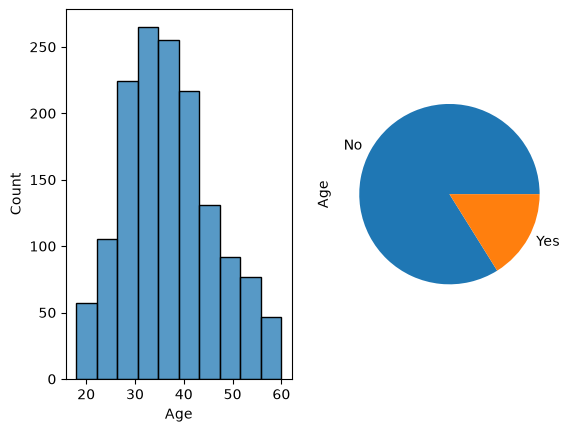

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv('/Users/rayquaza/Desktop/important/6th sem/ML/EDAibm_hr_employee-attrition.csv')

num=df.select_dtypes(include='number').columns
cat=df.select_dtypes(exclude='number').columns
n=input("Enter the number col")
if n in num:
    no=df[n]
    mean=no.mean()
    median=no.median()
    mode=no.mode()[0]
    var=no.var()
    std=no.std()
    q3=no.quantile(0.75)
    q1=no.quantile(0.25)
    iqr=q3-q1
    lb=q1-1.5*iqr
    ub=q3+1.5*iqr
    out=no[(no<lb) | (no>ub)]
    print(f"Mean: {mean}, Median: {median}, Mode: {mode}, Variance: {var}, Standard Deviation: {std}, IQR: {iqr}, Outliers: {len(out)}")
    plt.subplot(1,2,1)
    sns.histplot(no,bins=10)
    plt.subplot(1,2,2)
    sns.boxplot(no)
else:
    print(f"{n} is not a numerical column.")
c=input("Enter the cat col")
if c in cat:
    ca=df[c].value_counts()
    inp=input("Enter the pie or bar")
    if inp=='pie':
        ca.plot(kind='pie')
    if inp=='bar':
        ca.plot(kind='bar')
else:
    print('invalid')

Correlation:               petal_length  sepal_length
petal_length      1.000000      0.871754
sepal_length      0.871754      1.000000, 
Covariance:               petal_length  sepal_length
petal_length      3.116278      1.274315
sepal_length      1.274315      0.685694


<Axes: >

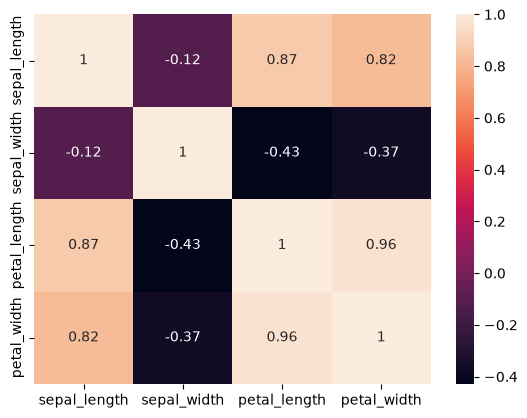

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=sns.load_dataset('iris')
y='petal_length'
x='sepal_length'
corr=df[['petal_length','sepal_length']].corr('pearson')
cov=df[['petal_length','sepal_length']].cov()
print(f"Correlation: {corr}, \nCovariance: {cov}")
ndf=df.iloc[:,:-1]
corr=ndf.corr()
cov=ndf.cov()
sns.heatmap(corr,annot=True)


In [19]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 6.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 7.2 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


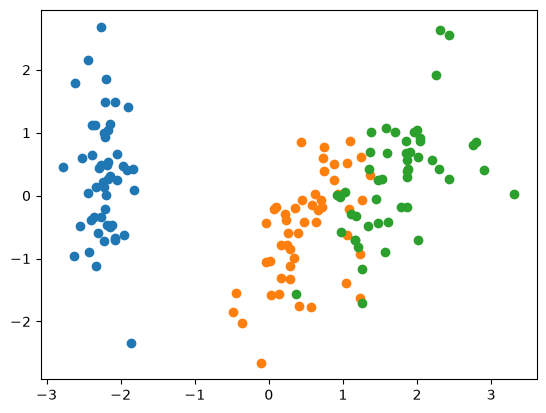

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
df=load_iris()
x=df.data
y=df.target
sc=StandardScaler()
x=sc.fit_transform(x)
pc=PCA(n_components=2)
p=pc.fit_transform(x)
pdf=pd.DataFrame(data=p,columns=['PC1','PC2'])  
pdf['species']=y
color= ['red','green','blue']
for i,color in zip([0,1,2],color):
    plt.scatter(
        pdf[pdf['species'] == i]['PC1'],
        pdf[pdf['species'] == i]['PC2']
    )
plt.plot()
plt.show()


In [34]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split as tts
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score as ass, f1_score as f1
df=load_iris()
x=df.data
y=df.target
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)
k_val=[1,3,5]
def nei(x_train,x_test,y_train,y_test,k_vals,weighted=False):
    results={}
    for k in k_vals:
        if weighted:
            knn=KNeighborsClassifier(n_neighbors=k,weights='distance')
        else:
            knn=KNeighborsClassifier(n_neighbors=k,weights='uniform')
        knn.fit(x_train,y_train)
        y_pred=knn.predict(x_test)
        acc=ass(y_test,y_pred)
        f11=f1(y_test,y_pred,average='weighted')
        results[k]={
            'acc':acc,
            'f1':f11
        }
    return results
w_mod=nei(x_train,x_test,y_train,y_test,k_val,weighted=True)
for k, w in w_mod.items():
    print(f'{k},{w["acc"]},{w["f1"]}')
nw_mod=nei(x_train,x_test,y_train,y_test,k_val,weighted=False)
for k, w in nw_mod.items():
    print(f'{k},{w["acc"]},{w["f1"]}')
for k in k_val:
    na=nw_mod[k]["acc"]
    w=w_mod[k]["acc"]
    print(f"{na},{w}")

1,1.0,1.0
3,1.0,1.0
5,1.0,1.0
1,1.0,1.0
3,1.0,1.0
5,1.0,1.0
1.0,1.0
1.0,1.0
1.0,1.0
